# UVA Analysis by Caleb Christian

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('ForeignGifts_edu.csv')
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


## 1. Isolate UVA

In [4]:
uva = df[df['Institution Name'] == 'University of Virginia'].copy()
uva

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26235,26236,374500,University of Virginia,Charlottesville,VA,41822,3565,Monetary Gift,ENGLAND,West Yorkshire Police
26236,26237,374500,University of Virginia,Charlottesville,VA,41870,12265,Contract,ISRAEL,CureTech Ltd
26237,26238,374500,University of Virginia,Charlottesville,VA,41873,8187,Monetary Gift,ISRAEL,Branco Weiss Institute
26238,26239,374500,University of Virginia,Charlottesville,VA,41887,6437,Contract,ISRAEL,NovoCure Ltd
26239,26240,374500,University of Virginia,Charlottesville,VA,41904,216943,Contract,ISRAEL,InSightec-Image Guide Treatment Ltd
...,...,...,...,...,...,...,...,...,...,...
26328,26329,374500,University of Virginia,Charlottesville,VA,43602,99885,Contract,SWEDEN,AutoLiv Development AB
26329,26330,374500,University of Virginia,Charlottesville,VA,43697,1000000,Monetary Gift,SWITZERLAND,Lawrence D & Karin S Howell
26330,26331,374500,University of Virginia,Charlottesville,VA,43796,500000,Monetary Gift,GUERNSEY,Harvest Group Holding (PTC Limited)
26331,26332,374500,University of Virginia,Charlottesville,VA,43803,146810,Contract,THE NETHERLANDS,Pantarhei Oncology BV


## 2. Where does UVA foreign money come from?

In [7]:
uva_countries = uva.groupby('Country of Giftor')['Foreign Gift Amount'].agg(['sum', 'count', 'mean'])
uva_countries.head()

,sum,count,mean
Country of Giftor,,,
BANGLADESH,4228589,10,422858.900000
BERMUDA,900000,1,900000.000000
ENGLAND,1950666,31,62924.709677
FINLAND,1008384,7,144054.857143
FRANCE,250383,5,50076.600000


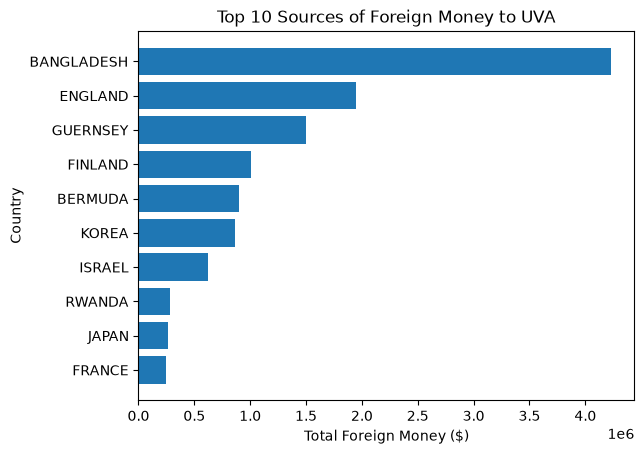

In [ ]:
#made a graph to represent top 10 places UVA gets money from
top_uva_countries = uva_countries['sum'].head(10).sort_values()

plt.barh(top_uva_countries.index, top_uva_countries.values)
plt.xlabel('Total Foreign Money ($)')
plt.ylabel('Country')
plt.title('Top 10 Sources of Foreign Money to UVA')
plt.show()

## 3. Gift type at UVA

In [9]:
uva_types = uva.groupby('Gift Type')['Foreign Gift Amount'].agg(['sum', 'count'])
uva_types

,sum,count
Gift Type,,
Contract,14807636,64
Monetary Gift,7381602,34


More money was coming in through contracts

## 4. Comparing UVA with other institutions

In [19]:
#named them enemies as a joke cause UVA the best
enemies = [
    'University of North Carolina - Chapel Hill',
    'University of Michigan - Ann Arbor',
    'University of California, Berkeley',
    'University of California, Los Angeles',
    'Duke University'
]

enemy_df = df[df['Institution Name'].isin(enemies)]
enemy_summary = enemy_df.groupby('Institution Name')['Foreign Gift Amount'].agg(['sum', 'count', 'mean', 'median'])
enemy_summary = enemy_summary.sort_values('sum', ascending=False)
enemy_summary

,sum,count,mean,median
Institution Name,,,,
Duke University,343699498,145,2.370341e+06,566606.0
"University of California, Berkeley",294479904,394,7.474109e+05,424025.0
University of Michigan - Ann Arbor,287336783,715,4.018696e+05,200000.0
"University of California, Los Angeles",242146363,3916,6.183513e+04,250.0
University of North Carolina - Chapel Hill,41292544,286,1.443795e+05,33548.0


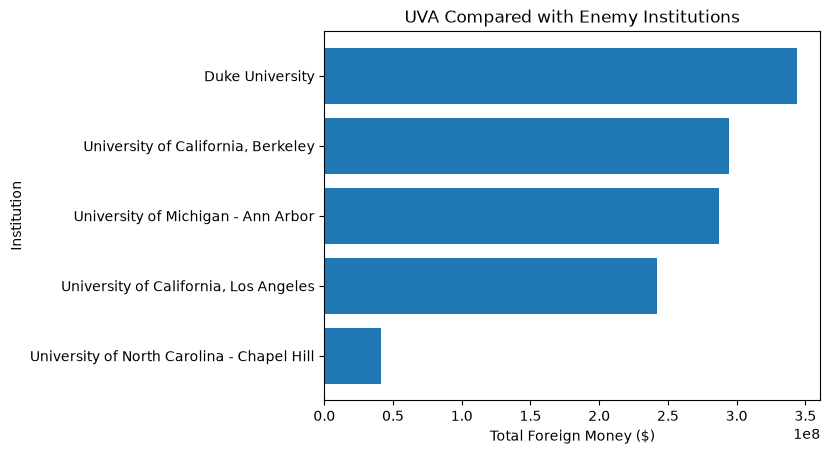

In [18]:
enemy_plot = enemy_summary['sum'].sort_values()

plt.barh(enemy_plot.index, enemy_plot.values)
plt.xlabel('Total Foreign Money ($)')
plt.ylabel('Institution')
plt.title('UVA Compared with Enemy Institutions')
plt.show()

## 5. Compare UVA with the overall market

In [28]:
institution_totals = df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)

uva_total = uva['Foreign Gift Amount'].sum()
uva_rank = institution_totals.rank(ascending=False, method='min')['University of Virginia']
uva_percentile = (institution_totals < uva_total).mean() * 100

print('Number of institutions:', len(institution_totals))
print('UVA rank by how much they get:', int(uva_rank))
print('UVA percentile:', round(uva_percentile, 1))

Number of institutions: 318
UVA rank by how much they get: 101
UVA percentile: 68.2


## 6. Find countries that other unis receive money from but UVA does not get

In [23]:
uva_country_set = set(uva['Country of Giftor'].dropna())
enemy_country_totals = enemy_df.groupby('Country of Giftor')['Foreign Gift Amount'].agg(['sum', 'count', 'mean'])
enemy_opportunities = enemy_country_totals[
    ~enemy_country_totals.index.isin(uva_country_set)
]
enemy_opportunities = enemy_opportunities.sort_values('sum', ascending=False)
enemy_opportunities.head(10)

,sum,count,mean
Country of Giftor,,,
CHINA,85199585,620,1.374187e+05
GERMANY,57669714,274,2.104734e+05
HONG KONG,52549248,356,1.476102e+05
CANADA,50142301,710,7.062296e+04
KAZAKHSTAN,43533449,18,2.418525e+06
SAUDI ARABIA,42923652,39,1.100606e+06
IRELAND,39108341,25,1.564334e+06
TAIWAN,25042685,155,1.615657e+05
DENMARK,23511838,44,5.343600e+05


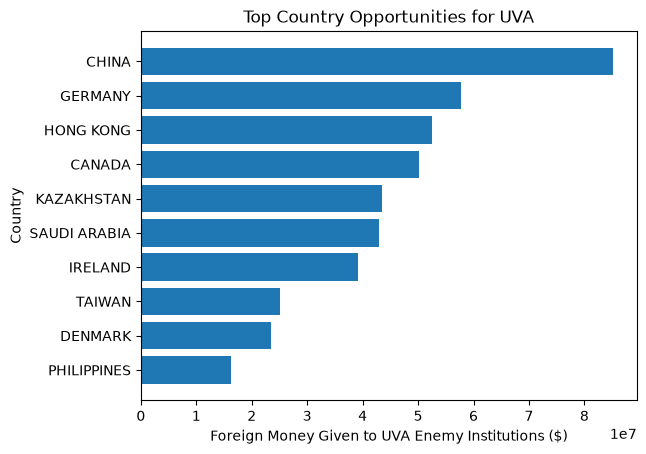

In [24]:
opportunity_plot = enemy_opportunities['sum'].head(10).sort_values()
plt.barh(opportunity_plot.index, opportunity_plot.values)
plt.xlabel('Foreign Money Given to UVA Enemy Institutions ($)')
plt.ylabel('Country')
plt.title('Top Country Opportunities for UVA')
plt.show()

## 7. Find orgs already funding schools that arent UVA

In [26]:
uva_giftors = set(uva['Giftor Name'].dropna())

enemy_giftors = enemy_df.dropna(subset=['Giftor Name']).groupby(
    ['Giftor Name', 'Country of Giftor']
)['Foreign Gift Amount'].agg(['sum', 'count'])

enemy_giftors = enemy_giftors.sort_values('sum', ascending=False)

new_enemy_giftors = enemy_giftors[
    ~enemy_giftors.index.get_level_values('Giftor Name').isin(uva_giftors)
]

new_enemy_giftors.head(15)

,,sum,count
Giftor Name,Country of Giftor,,
Sanofi-Aventis Recerche,FRANCE,62106706,4
Sanofi-Aventis Recherche,FRANCE,58520202,5
THE JAPAN FOUNDATION TADASHI YANAI,JAPAN,25000000,1
University of Nazarbayev,KAZAKHSTAN,21928213,6
BASF Corporation,GERMANY,20887750,20
Astrazeneca AB R&D Molandal,SWEDEN,20470948,2
HZNP Limited,IRELAND,17981676,3
Commission on Higher Education,PHILIPPINES,16325267,12
Astra Zeneca,SWEDEN,15236418,1


## 8. Strategy

UVA should focus on countries that already give large amounts of money to similar universities but give little or no money to UVA. The best opportunities include China, Germany, Hong Kong, Canada, Kazakhstan, Saudi Arabia, and Ireland. For example, China gave over $85 million to the certain institutions, while Germany gave over $57 million and Hong Kong gave over $52 million.

UVA could then look at specific organizations from these countries that already give money to other universities. These organizations are more realistic targets because they have already shown that they are willing to fund American universities.

UVA should especially focus on both research contracts and monetary gifts because the earlier analysis showed that a large portion of UVA's current foreign funding comes from contracts.

## 9. Quant analysis

- UVA has 98 reported foreign transactions totaling about $22.2 million.
- UVA receives foreign money from 15 countries.
- UVA ranks about 101st out of 318 institutions in total foreign money.
- UVA is around the 68% among institutions by total foreign money.
- UVA receives about $14.8 million through contracts and $7.4 million through monetary gifts, meaning contracts account for roughly two-thirds of UVA foreign funding.